In [1]:
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
import matplotlib.pyplot as plt
import time


import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

In [2]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()


In [3]:
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

In [4]:
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

In [5]:
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001   # mesh_size è il parametro h — cioè la dimensione caratteristica degli elementi della mesh. 
# Indica la lunghezza massima (o tipica) dello spigolo di un triangolo. Errore scala con tale taglia: ‖u − u_h‖ ≤ C · h^k

In [6]:
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

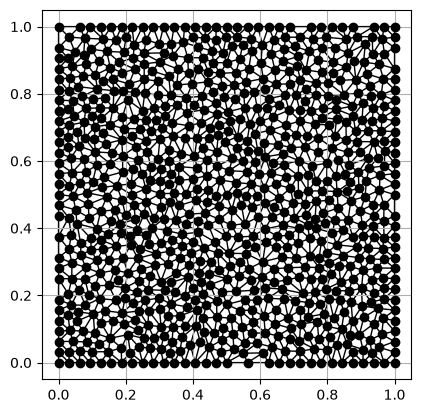

In [7]:
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

In [8]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [9]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [10]:
pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs
# I DOFs (Degrees of Freedom) sono i valori incogniti che il metodo FEM deve calcolare — cioè i valori della soluzione nei punti "liberi" della mesh.
# In FEM non cerchi la funzione continua u(x) direttamente — la approssimi come combinazione lineare di funzioni base. I DOFs sono i coefficienti uᵢ u_h(x) = Σᵢ uᵢ · φᵢ(x)

SOLUZIONE esatta presa da STOKESMOR (con al posto di 2 il parametro mu_1 generico)

In [11]:
print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


In [12]:
def pressure_exact(x, y, z):
    return np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * y)


def pressure_exact_gradient(x, y, z):
    return np.array([ +mu_1 * np.pi * np.cos(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * y),
        -mu_1 * np.pi * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y),
        0.0])


def speed_x_exact(x, y, z):
    return ( +0.5 * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y) )


def speed_y_exact(x, y, z):
    return ( -0.5 * np.sin(mu_1 * np.pi * y) * np.sin(mu_1 * np.pi * y) * np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * x))


def speed_x_exact_laplacian(x, y, z):
    return ( +2.0 * mu_1 * mu_1 * np.pi * np.pi * (2.0 * np.cos(2.0 * mu_1 * np.pi * x) - 1.0) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y))


def speed_y_exact_laplacian(x, y, z):
    return ( -2.0 * mu_1 * mu_1 * np.pi * np.pi * (2.0 * np.cos(2.0 * mu_1 * np.pi * y) - 1.0) * np.sin(mu_1 * np.pi * x)  * np.cos(mu_1 * np.pi * x))

#  servono per il termine convettivo
def speed_x_exact_dx(x, y, z):
    return ( mu_1 * np.pi * np.sin(mu_1 * np.pi * x) * np.cos(mu_1 * np.pi * x) * np.sin(mu_1 * np.pi * y) * np.cos(mu_1 * np.pi * y))

def speed_x_exact_dy(x, y, z):
    return (0.5 * mu_1 * np.pi* np.sin(mu_1 * np.pi * x)**2* np.cos(2.0 * mu_1 * np.pi * y))

def speed_y_exact_dx(x, y, z):
    return (-0.5 * mu_1 * np.pi* np.sin(mu_1 * np.pi * y)**2* np.cos(2.0 * mu_1 * np.pi * x))

def speed_y_exact_dy(x, y, z):
    return (-mu_1 * np.pi* np.sin(mu_1 * np.pi * y)* np.cos(mu_1 * np.pi * y)* np.sin(mu_1 * np.pi * x)* np.cos(mu_1 * np.pi * x))


#### Calcolo degli operatori che è possibile calcolare online 
Non dipendono dal parametro,
nu_term fissato a 1 perchè il parametro verrà gestito in un secondo momento

In [13]:
def nu_term(x, y, z):  
    return 1.0
def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])

A_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_dofs_data,
        speed_reference_element_data, speed_reference_element_data, nu_term)
J_A_x = other_ut.make_np_sparse(A_op.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
J_A_y = other_ut.make_np_sparse(A_op.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])

B_x_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, pressure_dofs_data,
    speed_reference_element_data, pressure_reference_element_data, b_x_term)
B_y_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, pressure_dofs_data,
    speed_reference_element_data, pressure_reference_element_data, b_y_term)

J_B_x  = other_ut.make_np_sparse(B_x_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0])
J_B_y  = other_ut.make_np_sparse(B_y_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_op.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs], True)

## Funzione di Newton per trovare soluzione FOM (produce snapshots)

In [14]:
def find_FOM_newton(J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs):

    # inizializzazione
    u_x_numeric = np.zeros(speed_n_dofs)
    u_y_numeric = np.zeros(speed_n_dofs)
    p_numeric   = np.zeros(pressure_n_dofs)
    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong   = np.zeros(pressure_n_strongs)
    
    last_sol_u = np.zeros(tot_dofs)
    
    residual_norm, solution_norm = 1.0, 1.0
    
    newton_tol, max_iterations, num_iteration = 1.0e-6, 100, 1

    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:
        c_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_x_numeric, u_y_numeric, u_x_strong, u_y_strong)
 
        J_C = other_ut.make_np_sparse(c_op.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_op.convective_rhs, np.zeros(pressure_n_dofs)])
 
        J_f = f_S - f_C - J_S @ u_k
        du  = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)

        u_k = u_k + du        
 
        u_x_numeric = u_k[:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2*speed_n_dofs]
        p_numeric   = u_k[2*speed_n_dofs:]
 
        du_x = du[:speed_n_dofs]
        du_y = du[speed_n_dofs:2*speed_n_dofs]
        dp   = du[2*speed_n_dofs:]


        ## NORME ERRORI E RESIDUI

        du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
        du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     du_y,
                                                                                     du_y_strong)
        dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     pressure_dofs_data,
                                                                                     pressure_reference_element_data,
                                                                                     dp,
                                                                                     dp_strong)
        u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    u_x_numeric,
                                                                                    u_x_strong,
                                                                                    speed_x_exact)
        u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    u_y_numeric,
                                                                                    u_y_strong,
                                                                                    speed_y_exact)
        p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    p_numeric,
                                                                                    p_strong,
                                                                                    pressure_exact)
           
        solution_norm = np.sqrt(u_x_error_L2.numeric_norm_l2 * u_x_error_L2.numeric_norm_l2 + 
                               u_y_error_L2.numeric_norm_l2 * u_y_error_L2.numeric_norm_l2 +
                               p_error_L2.numeric_norm_l2 * p_error_L2.numeric_norm_l2);     # norma di u_k 
        residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                               du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                               dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);  # norma residui
    
        num_iteration += 1

        last_sol_u = u_k.copy()
 
    # Stampa quale criterio ha fermato Newton
    if residual_norm <= newton_tol * solution_norm:
        flag = True
    else:
        flag = False

    u_error = np.sqrt(u_x_error_L2.error_l2**2 +u_y_error_L2.error_l2**2)
    p_error = p_error_L2.error_l2
    
    u_norm = np.sqrt(u_x_error_L2.numeric_norm_l2**2 +u_y_error_L2.numeric_norm_l2**2)
    p_norm = p_error_L2.numeric_norm_l2
    
    u_error_rel = u_error / u_norm
    p_error_rel = p_error / p_norm
    
    return last_sol_u, flag, num_iteration, u_error, p_error, u_error_rel, p_error_rel

## Supremizer + POD
Applichiamo POD partitioned (distinguendo velocità e pressione e supremizer, quindi 3 POD differenti)

In [15]:
### define the training set

 # si potrebbe pensare a variare: 
snapshot_num = 100  # larghezza training set iniziale
tol = 1. - 1e-7   # qnt massima da spiegare con gli snapshot presi come base dello spazio ridotto
N_max = 20    # numero massimo di snapshots nella base dello spazio ridotto

mu1_range = [0.1, 10.0]   # dominio fornito da prof
mu2_range = [1.0, 3.0]
P = np.array([mu1_range, mu2_range])

np.random.seed(0)
training_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(snapshot_num, P.shape[0]))


In [16]:
# Serve per il supremizer
X_1 = other_ut.make_np_sparse(A_op.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [0, 0])
X_2 = other_ut.make_np_sparse(A_op.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [speed_n_dofs, speed_n_dofs])
B_1 = other_ut.make_np_sparse(B_x_op.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, 0])
B_2 = other_ut.make_np_sparse(B_y_op.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, speed_n_dofs])

#### Creazione snapshots (soluzioni high fidelity + supremizer)
per ogni scelta di parametri fissato si calcolano oltre agli operatori già calcolati "offline" anche gli operatori che dipendono dai parametri oppure sono non lineari: termine convettivo e forzante. Successivamente si chiama la funzione FOM che produce gli snapshots

In [17]:
#### snapshot matrices creation

snapshot_matrix_u = []  # sia u_x che u_y
snapshot_matrix_s = [] ### supremizer snapshot
snapshot_matrix_p = []

print("Performing training...")

it = 0
for mu in training_set:

  if it % 10 == 0:
      print("\tIterations", 2 * it, " /", training_set.size)
  it = it + 1

  mu_0 = mu[0]
  mu_1 = mu[1]

  def pressure_strong_function(marker, x, y, z):  # definisco qui perchè dipende dai parametri
    return pressure_exact(x, y, z)
    
  p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
  def speed_x_strong_function(marker, x, y, z):   # definisco qui perchè dipende dai parametri
        return speed_x_exact(x, y, z)
  def speed_y_strong_function(marker, x, y, z):  # definisco qui perchè dipende dai parametri
        return speed_y_exact(x, y, z)
    
  u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_x_strong_function)
  u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_y_strong_function)
    
 
  def f_x_function(x, y, z):    # definisco qui perchè dipende dai parametri (nonostante la soluzione sia la stessa di stokes la forzante è diversa perchè c'è in più il termine convettivo
        ux = speed_x_exact(x, y, z)
        uy = speed_y_exact(x, y, z)
        convection = (ux * speed_x_exact_dx(x, y, z)+ uy * speed_x_exact_dy(x, y, z) )
        pressure = pressure_exact_gradient(x, y, z)[0]
        laplacian = speed_x_exact_laplacian(x, y, z)
        return -mu_0 * laplacian + convection + pressure
    
  def f_y_function(x, y, z):  # definisco qui perchè dipende dai parametri
        ux = speed_x_exact(x, y, z)
        uy = speed_y_exact(x, y, z)
        convection = (ux * speed_y_exact_dx(x, y, z)+ uy * speed_y_exact_dy(x, y, z))
        pressure = pressure_exact_gradient(x, y, z)[1]
        laplacian = speed_y_exact_laplacian(x, y, z)
        return -mu_0 * laplacian + convection + pressure
    

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y   # definisco jacobiano totale
  
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,   
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

  f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])  # forzante
    
  snapshot_solution, flag, num_iter, err_u, err_p, u_error_rel, p_error_rel = find_FOM_newton(J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs)  
    
  snapshot_u = snapshot_solution[0:2 * speed_n_dofs]
  snapshot_matrix_u.append(np.copy(snapshot_u))
  
  snapshot_p = snapshot_solution[2 * speed_n_dofs:]
  snapshot_matrix_p.append(np.copy(snapshot_p))

  snapshot_s = scipy.sparse.linalg.spsolve(X_1 + X_2, np.transpose(B_1 + B_2) @ snapshot_p)
  snapshot_matrix_s.append(np.copy(snapshot_s)) 

snapshot_matrix_u = np.array(snapshot_matrix_u)
snapshot_matrix_s = np.array(snapshot_matrix_s)
snapshot_matrix_p = np.array(snapshot_matrix_p)  

print("Training performed")

Performing training...
	Iterations 0  / 200
	Iterations 20  / 200
	Iterations 40  / 200
	Iterations 60  / 200
	Iterations 80  / 200
	Iterations 100  / 200
	Iterations 120  / 200
	Iterations 140  / 200
	Iterations 160  / 200
	Iterations 180  / 200
Training performed


#### Prelevazione snapshots più informativi e creazione quindi della base

In [18]:
inner_product_u = X_1 + X_2

In [19]:
def eig_analysis(C, N_max=None, tol=1e-9):
    L_e, VM_e = np.linalg.eigh(C)

    # Ordina autovalori e autovettori in ordine decrescente
    idx = np.argsort(L_e)[::-1]
    L_e = L_e[idx]
    VM_e = VM_e[:, idx]

    eigenvalues = []
    eigenvectors = []

    for i in range(len(L_e)):
        eigenvalues.append(L_e[i])
        eigenvectors.append(VM_e[:, i])

    total_energy = sum(eigenvalues)
    retained_energy_vector = np.cumsum(eigenvalues)
    relative_retained_energy = retained_energy_vector / total_energy

    N = np.argmax(relative_retained_energy >= tol) + 1

    if N_max is not None:
        N = min(N, N_max)

    return N, eigenvectors



In [20]:
### covariance matrix

C_u = snapshot_matrix_u @ inner_product_u @ np.transpose(snapshot_matrix_u)
C_s = snapshot_matrix_s @ inner_product_u @ np.transpose(snapshot_matrix_s)
C_p = snapshot_matrix_p @ np.transpose(snapshot_matrix_p)

N_u, eigs_u = eig_analysis(C_u, N_max=N_max, tol=tol)
N_s, eigs_s = eig_analysis(C_s, N_max=N_max, tol=tol)
N_p, eigs_p = eig_analysis(C_p, N_max=N_max, tol=tol)

print(N_u, N_s, N_p)
reduced_u_dof = N_u + N_s

16 20 19


In [21]:
def create_basis_functions_matrix(N, snapshot_matrix, eigenvectors, inner_product=None):
  
  basis_functions = []
  
  for n in range(N):
    eigenvector =  eigenvectors[n]
    basis = np.transpose(snapshot_matrix)@eigenvector
    if inner_product!= None:
      norm = np.sqrt(np.transpose(basis) @ inner_product @ basis) ## metti inner product
    else:
      norm = np.sqrt(np.transpose(basis) @ basis)
    basis /= norm
    basis_functions.append(np.copy(basis))

  basis_function_matrix = np.transpose(np.array(basis_functions))
  
  return basis_function_matrix

In [22]:
basis_functions_u = create_basis_functions_matrix(N_u, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
basis_functions_s = create_basis_functions_matrix(N_s, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
basis_functions_p = create_basis_functions_matrix(N_p, snapshot_matrix_p, eigs_p)

In [23]:
print(basis_functions_u.shape)
print(basis_functions_p.shape)
print(basis_functions_u.shape[0] + basis_functions_p.shape[0])
print(basis_functions_p.shape)

global_basis_function_matrix = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_s + N_p))
global_basis_function_matrix[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix[0:basis_functions_u.shape[0], N_u : N_u + N_s] = basis_functions_s
global_basis_function_matrix[basis_functions_u.shape[0]:, N_u + N_s:] = basis_functions_p
print(global_basis_function_matrix.shape)

global_basis_function_matrix_no_sup = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_p))
global_basis_function_matrix_no_sup[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix_no_sup[basis_functions_u.shape[0]:, N_u:] = basis_functions_p

(5932, 16)
(829, 19)
6761
(829, 19)
(6761, 55)


In [24]:
def assemble_reduced_matrix(basis, fom_matrix):
  return np.transpose(basis) @ (fom_matrix) @ basis

def assemble_reduced_vector(basis, fom_vector):
  return np.transpose(basis) @ (fom_vector)

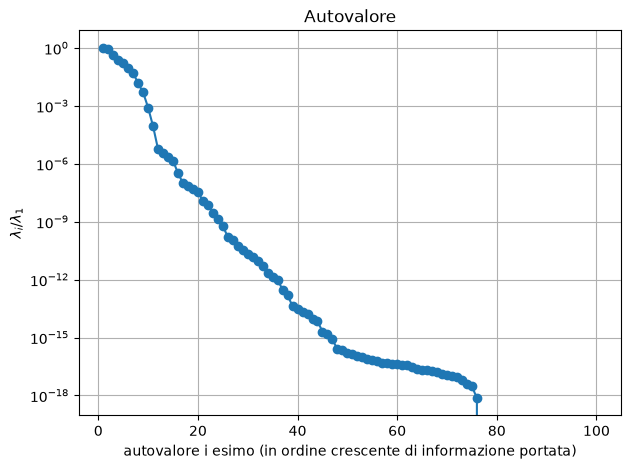

In [25]:
## GRAFICO: valore autovalori (quantità informazione portata)
eigvals = np.linalg.eigvalsh(C_u)
eigvals = np.sort(eigvals)[::-1]

plt.figure(figsize=(7,5))
plt.semilogy(range(1,len(eigvals)+1), eigvals/eigvals[0], '-o')

plt.xlabel("autovalore i esimo (in ordine crescente di informazione portata)")
plt.ylabel(r"$\lambda_i/\lambda_1$")
plt.title("Autovalore")
plt.grid(True)

plt.show()

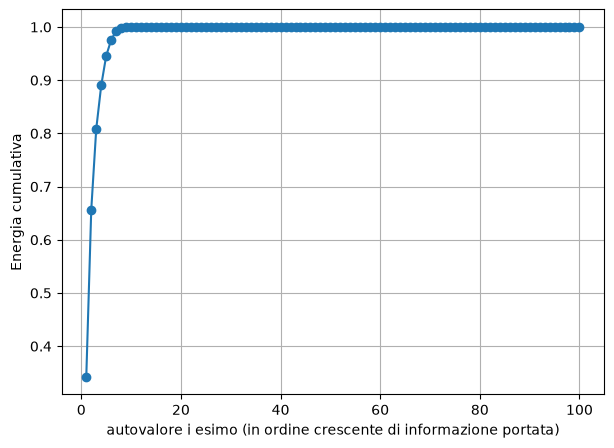

In [26]:
## GRAFICO: energia/informazione cumulata
energy = np.cumsum(eigvals)/np.sum(eigvals)

plt.figure(figsize=(7,5))

plt.plot(range(1,len(energy)+1), energy,'-o')

plt.xlabel("autovalore i esimo (in ordine crescente di informazione portata)")
plt.ylabel("Energia cumulativa")
plt.grid(True)

plt.show()

### Funzione per risoluzione sistema ridotto MOR
Significa che internamente si proietterà la soluzione e si risolverà il sistema con dimensione ridotta

In [27]:
def find_ROM_newton(global_basis_function_matrix, J_S, f_S):
    newton_tol=1e-6
    max_iterations=30
    u_k = reduced_initial_solution.copy()
    residual_norm = 1
    solution_norm = 0
    num_iteration = 0
    full_solution = global_basis_function_matrix @ u_k
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)

    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:

        u_x_numeric = full_solution[:speed_n_dofs]
        u_y_numeric = full_solution[speed_n_dofs:2*speed_n_dofs]
        p_numeric = full_solution[2*speed_n_dofs:]
        
        # termine convettivo
        c_op = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_x_numeric, u_y_numeric, u_x_strong, u_y_strong)

        J_C = other_ut.make_np_sparse(c_op.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_op.convective_rhs, np.zeros(pressure_n_dofs)])
 
        J_f = f_S - f_C - J_S @ full_solution
        J_tot = J_S + J_C

        J_tot_red = global_basis_function_matrix.transpose() @ J_tot @ global_basis_function_matrix 
        J_f_red = global_basis_function_matrix.transpose() @ J_f
        du = np.linalg.solve(J_tot_red, J_f_red)

        u_k = u_k + du        

         ## NORME ERRORI E RESIDUI

        full_solution = global_basis_function_matrix @ u_k
        du_full = global_basis_function_matrix @ du


        u_x_numeric = full_solution[:speed_n_dofs]
        u_y_numeric = full_solution[speed_n_dofs:2*speed_n_dofs]
        p_numeric = full_solution[2*speed_n_dofs:]

        du_x = du_full[:speed_n_dofs]
        du_y = du_full[speed_n_dofs:2*speed_n_dofs]
        dp = du_full[2*speed_n_dofs:]
    

        du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
        du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     du_y,
                                                                                     du_y_strong)
        dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     pressure_dofs_data,
                                                                                     pressure_reference_element_data,
                                                                                     dp,
                                                                                     dp_strong)

        u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    u_x_numeric,
                                                                                    u_x_strong,
                                                                                    speed_x_exact)
        u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    u_y_numeric,
                                                                                    u_y_strong,
                                                                                    speed_y_exact)
        p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    p_numeric,
                                                                                    p_strong,
                                                                                    pressure_exact)

        solution_norm = np.sqrt(u_x_error_L2.numeric_norm_l2 * u_x_error_L2.numeric_norm_l2 + 
                               u_y_error_L2.numeric_norm_l2 * u_y_error_L2.numeric_norm_l2 +
                               p_error_L2.numeric_norm_l2 * p_error_L2.numeric_norm_l2);     # norma di u_k 
        residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                               du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                               dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);
        num_iteration += 1

    # Stampa quale criterio ha fermato Newton
    if residual_norm <= newton_tol * solution_norm:
        flag = True
    else:
        flag = False

    u_error = np.sqrt(u_x_error_L2.error_l2**2 +u_y_error_L2.error_l2**2)
    p_error = p_error_L2.error_l2
    
    u_norm = np.sqrt(u_x_error_L2.numeric_norm_l2**2 +u_y_error_L2.numeric_norm_l2**2)
    p_norm = p_error_L2.numeric_norm_l2
    
    u_error_rel = u_error / u_norm
    p_error_rel = p_error / p_norm
    
    return full_solution, u_k, flag, num_iteration, u_error, p_error, u_error_rel, p_error_rel

## PROVA: deduzione soluzione tramite ROM con nuovi parametri

In [28]:
### FASE ONLINE: VALUTAZIONE NUOVO PARAMETRO ###
mu_0 = 0.1
mu_1 = 1


def pressure_strong_function(marker, x, y, z):  
    return pressure_exact(x, y, z)

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
def speed_x_strong_function(marker, x, y, z):  
    return speed_x_exact(x, y, z)
def speed_y_strong_function(marker, x, y, z):  
    return speed_y_exact(x, y, z)

# soluzioni esatte

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_y_strong_function)


# diverse da STOKESROM perchè c'è il termine convettivo, comunque sono costruite in modo tale che la soluzione sopra definita sia esatta
def f_x_function(x, y, z):
    ux = speed_x_exact(x, y, z)
    uy = speed_y_exact(x, y, z)
    convection = (ux * speed_x_exact_dx(x, y, z)+ uy * speed_x_exact_dy(x, y, z) )
    pressure = pressure_exact_gradient(x, y, z)[0]
    laplacian = speed_x_exact_laplacian(x, y, z)
    return -mu_0 * laplacian + convection + pressure

def f_y_function(x, y, z):
    ux = speed_x_exact(x, y, z)
    uy = speed_y_exact(x, y, z)
    convection = (ux * speed_y_exact_dx(x, y, z)+ uy * speed_y_exact_dy(x, y, z))
    pressure = pressure_exact_gradient(x, y, z)[1]
    laplacian = speed_y_exact_laplacian(x, y, z)
    return -mu_0 * laplacian + convection + pressure

f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])


# Riduzione online
reduced_initial_solution = np.zeros(global_basis_function_matrix.shape[1])
J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

# calcolo soluzione ridotta
reduced_solution_FE_basis_full_dim, reduced_solution,flag, num_iterations, u_error, p_error, u_error_rel, p_error_rel = find_ROM_newton(global_basis_function_matrix, J_S, f_S)

In [29]:
reduced_u_x_FE = reduced_solution_FE_basis_full_dim[0:speed_n_dofs]
reduced_u_y_FE = reduced_solution_FE_basis_full_dim[speed_n_dofs:2 * speed_n_dofs]
reduced_p_FE = reduced_solution_FE_basis_full_dim[2 * speed_n_dofs:]

In [30]:
reduced_u_x_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data, reduced_u_x_FE,
                                                                                         u_x_strong,
                                                                       speed_x_exact)
reduced_u_y_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         reduced_u_y_FE,
                                                                                         u_y_strong,
                                                                       speed_y_exact)
reduced_p_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       pressure_dofs_data,
                                                                                         reduced_p_FE,
                                                                                         p_strong,
                                                                       pressure_exact)

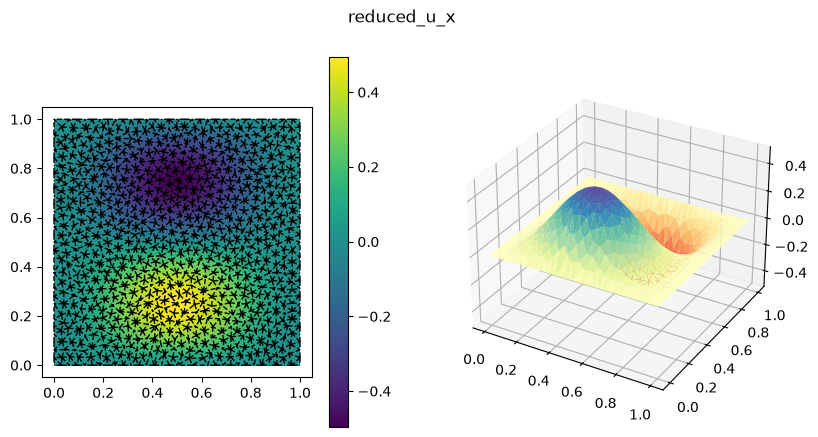

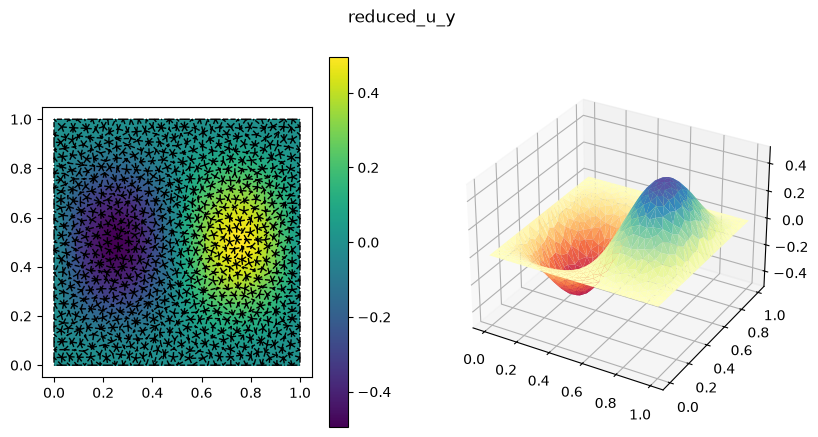

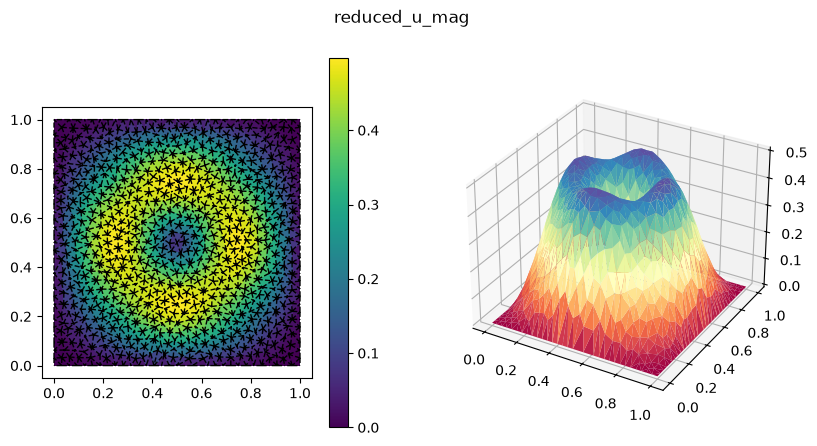

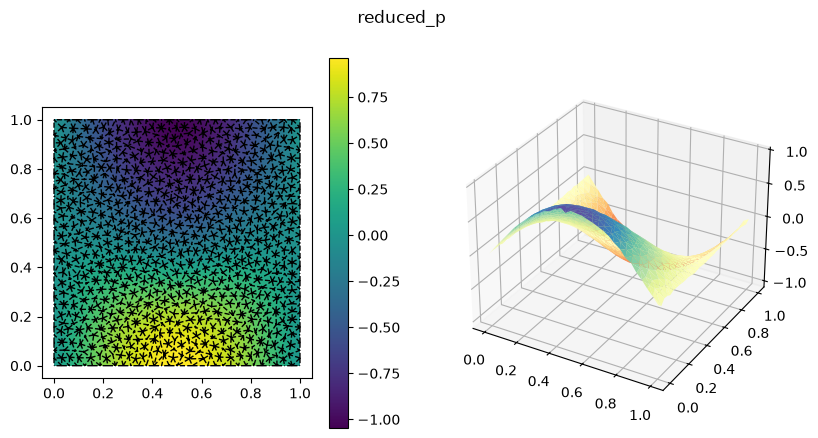

In [31]:
vtk_utilities.export_solution_2(export_solution_path + '/reduced_u_x',
                                mesh, 
                                reduced_u_x_on_cell0Ds.numeric_solution)
vtk_utilities.export_solution_2(export_solution_path + '/reduced_u_y',
                                mesh, 
                                reduced_u_y_on_cell0Ds.numeric_solution)
vtk_utilities.export_solution_2(export_solution_path + '/reduced_p',
                                mesh, 
                                reduced_p_on_cell0Ds.numeric_solution)
other_ut.plot_solution(mesh, reduced_u_x_on_cell0Ds.numeric_solution, "reduced_u_x") 
other_ut.plot_solution(mesh, reduced_u_y_on_cell0Ds.numeric_solution, "reduced_u_y")
other_ut.plot_solution(mesh, np.sqrt(reduced_u_x_on_cell0Ds.numeric_solution * reduced_u_x_on_cell0Ds.numeric_solution + reduced_u_y_on_cell0Ds.numeric_solution * reduced_u_y_on_cell0Ds.numeric_solution), "reduced_u_mag")
other_ut.plot_solution(mesh, reduced_p_on_cell0Ds.numeric_solution, "reduced_p") 

# VALIDAZIONI
In parte il codice seguente sarà un riutilizzo di quello precedente ma finalizzato alla validazione dei vari pezzi

## VALIDAZIONE 1: POD
All'aumentare del numero di snapshot considerati nella base l'errore medio nella loro proiezione su questa stessa base deve decrescere in modo monotono

In [32]:
 # Presa da ROMStokes
# Calcola l'errore assoluto o relativo tra due soluzioni discrete.
# Se viene fornita una matrice di prodotto interno (ad esempio la matrice
# di massa FEM), l'errore è misurato nella norma indotta da tale matrice;
# altrimenti viene utilizzata la norma euclidea.
def compute_error(fom_solution, rom_solution_FE_basis, inner_product=None, type_err="relative"):
    
    error_function_u = fom_solution - rom_solution_FE_basis
    
    if inner_product == None:
        inner_product_matrix = np.identity(fom_solution.shape[0])
    else:
      inner_product_matrix = inner_product
    
    error_norm_squared_component = np.transpose(error_function_u) @ inner_product_matrix @ error_function_u
    absolute_error = np.sqrt(abs(error_norm_squared_component))
    
    if type_err == "absolute":
      return absolute_error
    else:
      full_solution_norm_squared_component = np.transpose(fom_solution) @  inner_product_matrix @ fom_solution
      relative_error = absolute_error/np.sqrt(abs(full_solution_norm_squared_component))
    
      return relative_error

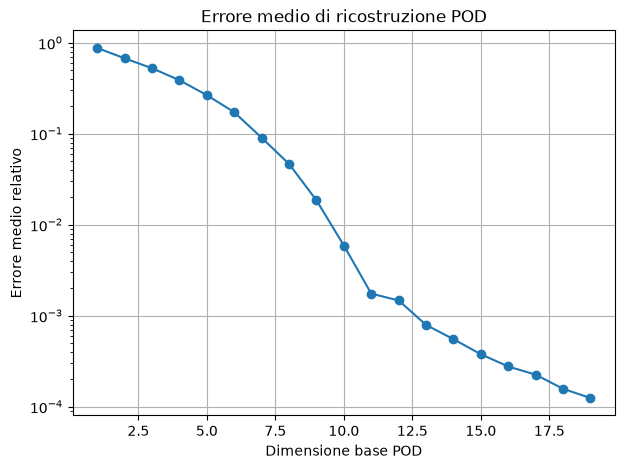

In [33]:
N_test =  min(N_max,snapshot_matrix_u.shape[0])
errore_medio = []

for N in range(1, N_test):

    # Base POD con i primi N modi
    basis = create_basis_functions_matrix( N, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
    errori = []
    # ricostruzione di tutti gli snapshot
    for snapshot in snapshot_matrix_u:
        # coefficienti POD
        alpha = basis.T @ inner_product_u @ snapshot
        # ricostruzione
        snapshot_rec = basis @ alpha
        # errore relativo nella norma energetica
        err = np.sqrt((snapshot - snapshot_rec).T@ inner_product_u@ (snapshot - snapshot_rec))
        norm = np.sqrt(snapshot.T @ inner_product_u @ snapshot)
        errori.append(err / norm)
    errore_medio.append(np.mean(errori))

plt.figure(figsize=(7,5))
plt.semilogy(range(1, len(errore_medio)+1), errore_medio, '-o')
plt.xlabel("Dimensione base POD")
plt.ylabel("Errore medio relativo")
plt.title("Errore medio di ricostruzione POD")
plt.grid(True)
plt.show()

## VALIDAZIONE 2: Confronto ROM-FOM
Si confronta ROM e FOM:
- in termini di accuratezza (distanza rispetto alla soluzione corretta)
- in termini di tempo necessario per risoluzione (nel MOR non considero il POD che è già avvenuto)
- Convergenza Newton
- Distanza reciproca delle soluzioni

Questo variando parametri 

In [34]:
num_coppie_par = 100  # larghezza training set iniziale

mu1_range = [0.1, 10.0]   # dominio fornito da prof
mu2_range = [1.0, 3.0]
P = np.array([mu1_range, mu2_range])

testing_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(num_coppie_par, P.shape[0]))



In [35]:
## Applicazione ROM e FOM al variare dei parametri
times_FOM = []
times_ROM = []
conv_flag_FOM = []
conv_flag_ROM = []
num_iter_FOM = []
num_iter_ROM = []
err_u_exact_ROM = [] 
err_p_exact_ROM = [] 
err_u_exact_FOM = [] 
err_p_exact_FOM = [] 
err_u_FOM_ROM  = []
err_p_FOM_ROM = []
err_u_exact_ROM_rel = [] 
err_p_exact_ROM_rel = [] 
err_u_exact_FOM_rel = [] 
err_p_exact_FOM_rel = [] 

for mu in testing_set:
  mu_0 = mu[0]
  mu_1 = mu[1]

  def pressure_strong_function(marker, x, y, z):  # definisco qui perchè dipende dai parametri
    return pressure_exact(x, y, z)
    
  p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
  def speed_x_strong_function(marker, x, y, z):   # definisco qui perchè dipende dai parametri
        return speed_x_exact(x, y, z)
  def speed_y_strong_function(marker, x, y, z):  # definisco qui perchè dipende dai parametri
        return speed_y_exact(x, y, z)
    
  u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_x_strong_function)
  u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_y_strong_function)


  # FOM starting
  start_FOM = time.perf_counter()
 
  def f_x_function(x, y, z):    # definisco qui perchè dipende dai parametri (nonostante la soluzione sia la stessa di stokes la forzante è diversa perchè c'è in più il termine convettivo
        ux = speed_x_exact(x, y, z)
        uy = speed_y_exact(x, y, z)
        convection = (ux * speed_x_exact_dx(x, y, z)+ uy * speed_x_exact_dy(x, y, z) )
        pressure = pressure_exact_gradient(x, y, z)[0]
        laplacian = speed_x_exact_laplacian(x, y, z)
        return -mu_0 * laplacian + convection + pressure
    
  def f_y_function(x, y, z):  # definisco qui perchè dipende dai parametri
        ux = speed_x_exact(x, y, z)
        uy = speed_y_exact(x, y, z)
        convection = (ux * speed_y_exact_dx(x, y, z)+ uy * speed_y_exact_dy(x, y, z))
        pressure = pressure_exact_gradient(x, y, z)[1]
        laplacian = speed_y_exact_laplacian(x, y, z)
        return -mu_0 * laplacian + convection + pressure
    

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y   # definisco jacobiano totale
  
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,   
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

  f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])  # forzante
    
  FOM_solution, type_conv_fom, num_iter_fom, err_u, err_p, u_error_rel, p_error_rel = find_FOM_newton(J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs)

  elapsed = time.perf_counter() - start_FOM
  times_FOM.append(elapsed)
  conv_flag_FOM.append(type_conv_fom)
  num_iter_FOM.append(num_iter_fom)
  err_u_exact_FOM.append(err_u)
  err_p_exact_FOM.append(err_p)
  err_u_exact_FOM_rel.append(u_error_rel)
  err_p_exact_FOM_rel.append(p_error_rel)
    
  # FOM finishing

  # ROM starting
  start_ROM = time.perf_counter()

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y
 
  def f_x_function(x, y, z):    # definisco qui perchè dipende dai parametri (nonostante la soluzione sia la stessa di stokes la forzante è diversa perchè c'è in più il termine convettivo
        ux = speed_x_exact(x, y, z)
        uy = speed_y_exact(x, y, z)
        convection = (ux * speed_x_exact_dx(x, y, z)+ uy * speed_x_exact_dy(x, y, z) )
        pressure = pressure_exact_gradient(x, y, z)[0]
        laplacian = speed_x_exact_laplacian(x, y, z)
        return -mu_0 * laplacian + convection + pressure
    
  def f_y_function(x, y, z):  # definisco qui perchè dipende dai parametri
        ux = speed_x_exact(x, y, z)
        uy = speed_y_exact(x, y, z)
        convection = (ux * speed_y_exact_dx(x, y, z)+ uy * speed_y_exact_dy(x, y, z))
        pressure = pressure_exact_gradient(x, y, z)[1]
        laplacian = speed_y_exact_laplacian(x, y, z)
        return -mu_0 * laplacian + convection + pressure
    

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y   # definisco jacobiano totale
  
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,   
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

  f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])  # forzante

  reduced_initial_solution = np.zeros(global_basis_function_matrix.shape[1])
  reduced_solution_FE_basis_full_dim, reduced_solution, type_conv_rom, num_iter_rom, err_u, err_p, u_error_rel, p_error_rel = find_ROM_newton(global_basis_function_matrix, J_S, f_S)
    
  elapsed = time.perf_counter() - start_ROM
  times_ROM.append(elapsed)
  conv_flag_ROM.append(type_conv_rom)
  num_iter_ROM.append(num_iter_rom)
  err_u_exact_ROM.append(err_u)
  err_p_exact_ROM.append(err_p)
  err_u_exact_ROM_rel.append(u_error_rel)
  err_p_exact_ROM_rel.append(p_error_rel)

  # ROM finishing
  err_u_FOM_ROM.append(compute_error(FOM_solution[:2*speed_n_dofs],reduced_solution_FE_basis_full_dim[:2*speed_n_dofs],inner_product=inner_product_u ))
  err_p_FOM_ROM.append(compute_error(FOM_solution[2*speed_n_dofs:], reduced_solution_FE_basis_full_dim[2*speed_n_dofs:]))
  
    

In [36]:
print("\n==================== RISULTATI ====================\n")

print(f"Tempo medio FOM : {np.mean(times_FOM):.6f} s")
print(f"Tempo medio ROM : {np.mean(times_ROM):.6f} s")

print()

print(f"Errore medio velocità   (Esatta vs FOM): {np.mean(err_u_exact_FOM):.3e}")
print(f"Errore medio pressione  (Esatta vs FOM): {np.mean(err_p_exact_FOM):.3e}")
print(f"Errore relativo medio velocità   (Esatta vs FOM): {np.mean(err_u_exact_FOM_rel):.3e}")
print(f"Errore relativo medio pressione  (Esatta vs FOM): {np.mean(err_p_exact_FOM_rel):.3e}")

print()

print(f"Errore medio velocità   (Esatta vs ROM): {np.mean(err_u_exact_ROM):.3e}")
print(f"Errore medio pressione  (Esatta vs ROM): {np.mean(err_p_exact_ROM):.3e}")
print(f"Errore relativo medio velocità   (Esatta vs ROM): {np.mean(err_u_exact_ROM_rel):.3e}")
print(f"Errore relativo medio pressione  (Esatta vs ROM): {np.mean(err_p_exact_ROM_rel):.3e}")

print()

print(f"Errore medio velocità   (FOM vs ROM): {np.mean(err_u_FOM_ROM):.3e}")
print(f"Errore medio pressione  (FOM vs ROM): {np.mean(err_p_FOM_ROM):.3e}")

print()

print(f"Iterazioni medie Newton FOM : {np.mean(num_iter_FOM):.2f}")
print(f"Iterazioni medie Newton ROM : {np.mean(num_iter_ROM):.2f}")

print(f"Convergenze FOM: {sum(conv_flag_FOM)}/{len(conv_flag_FOM)}")
print(f"Convergenze ROM: {sum(conv_flag_ROM)}/{len(conv_flag_ROM)}")


==================== RISULTATI ====================

Tempo medio FOM : 1.293490 s
Tempo medio ROM : 1.047604 s

Errore medio velocità   (Esatta vs FOM): 1.540e-01
Errore medio pressione  (Esatta vs FOM): 8.896e+00
Errore relativo medio velocità   (Esatta vs FOM): 5.632e-01
Errore relativo medio pressione  (Esatta vs FOM): 9.799e-01

Errore medio velocità   (Esatta vs ROM): 1.540e-01
Errore medio pressione  (Esatta vs ROM): 8.896e+00
Errore relativo medio velocità   (Esatta vs ROM): 5.632e-01
Errore relativo medio pressione  (Esatta vs ROM): 9.800e-01

Errore medio velocità   (FOM vs ROM): 6.255e-04
Errore medio pressione  (FOM vs ROM): 3.264e-03

Iterazioni medie Newton FOM : 4.05
Iterazioni medie Newton ROM : 3.05
Convergenze FOM: 100/100
Convergenze ROM: 100/100


In [37]:
# Studio dell'influenza della tolleranza POD

N_max = 100

tolerances = [0.80, 0.85, 0.90, 0.95, 0.99, 0.9999, 0.999999]

err_u_mean = []
err_p_mean = []
Nu_vec = []
Ns_vec = []
Np_vec = []

for tol in tolerances:

    # ---------------- POD ----------------

    N_u, eigs_u = eig_analysis(C_u, N_max=N_max, tol=tol)
    N_s, eigs_s = eig_analysis(C_s, N_max=N_max, tol=tol)
    N_p, eigs_p = eig_analysis(C_p, N_max=N_max, tol=tol)
    Nu_vec.append(N_u)
    Ns_vec.append(N_s)
    Np_vec.append(N_p)

    basis_functions_u = create_basis_functions_matrix(N_u,snapshot_matrix_u,eigs_u,inner_product=inner_product_u)
    basis_functions_s = create_basis_functions_matrix(N_s,snapshot_matrix_s,eigs_s,inner_product=inner_product_u)
    basis_functions_p = create_basis_functions_matrix( N_p, snapshot_matrix_p, eigs_p)
    basis = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_s + N_p))
    basis[:basis_functions_u.shape[0], :N_u] = basis_functions_u
    basis[:basis_functions_u.shape[0], N_u:N_u+N_s] = basis_functions_s
    basis[basis_functions_u.shape[0]:, N_u+N_s:] = basis_functions_p

    # ---------------- ROM ----------------

    err_u = []
    err_p = []

    for mu in testing_set:
        mu_0 = mu[0]
        J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

        # forzante
        def f_x_function(x,y,z):
            ux = speed_x_exact(x,y,z)
            uy = speed_y_exact(x,y,z)
            return (-mu_0*speed_x_exact_laplacian(x,y,z)+ ux*speed_x_exact_dx(x,y,z)  + uy*speed_x_exact_dy(x,y,z)  + pressure_exact_gradient(x,y,z)[0])

        def f_y_function(x,y,z):
            ux = speed_x_exact(x,y,z)
            uy = speed_y_exact(x,y,z)
            return (-mu_0*speed_y_exact_laplacian(x,y,z)+ ux*speed_y_exact_dx(x,y,z)+ uy*speed_y_exact_dy(x,y,z)+ pressure_exact_gradient(x,y,z)[1])

        f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term( geometry_utilities, mesh, mesh_geometric_data, speed_dofs_data, speed_reference_element_data, speed_reference_element_data,f_x_function)
        f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,mesh,mesh_geometric_data,speed_dofs_data,speed_reference_element_data,speed_reference_element_data,f_y_function)
        f_S = np.concatenate([f_x,f_y,np.zeros(pressure_n_dofs)])
        reduced_initial_solution = np.zeros(basis.shape[1])

        ROM_solution, _, _, _, _, _, _, _ = find_ROM_newton(basis,J_S,f_S)
        FOM_solution, _, _, _, _, _, _ = find_FOM_newton(J_S,f_S,u_x_strong,u_y_strong,speed_n_dofs,pressure_n_dofs,tot_dofs)

        err_u.append(compute_error( FOM_solution[:2*speed_n_dofs], ROM_solution[:2*speed_n_dofs], inner_product=inner_product_u))
        err_p.append(compute_error( FOM_solution[2*speed_n_dofs:], ROM_solution[2*speed_n_dofs:]))

    err_u_mean.append(np.mean(err_u))
    err_p_mean.append(np.mean(err_p))

    print(f"tol={tol:.6f}  "
          f"(Nu,Ns,Np)=({N_u},{N_s},{N_p})  "
          f"u={err_u_mean[-1]:.2e}  "
          f"p={err_p_mean[-1]:.2e}")

tol=0.800000  (Nu,Ns,Np)=(3,2,2)  u=9.83e-01  p=7.48e-01
tol=0.850000  (Nu,Ns,Np)=(4,2,2)  u=5.27e-01  p=7.48e-01
tol=0.900000  (Nu,Ns,Np)=(5,3,3)  u=3.56e-01  p=6.67e-01
tol=0.950000  (Nu,Ns,Np)=(6,4,3)  u=3.77e-01  p=6.62e-01
tol=0.990000  (Nu,Ns,Np)=(7,5,5)  u=2.17e-01  p=2.55e-01
tol=0.999900  (Nu,Ns,Np)=(10,11,11)  u=1.62e-02  p=6.19e-02
tol=0.999999  (Nu,Ns,Np)=(14,17,17)  u=6.23e-04  p=7.51e-03


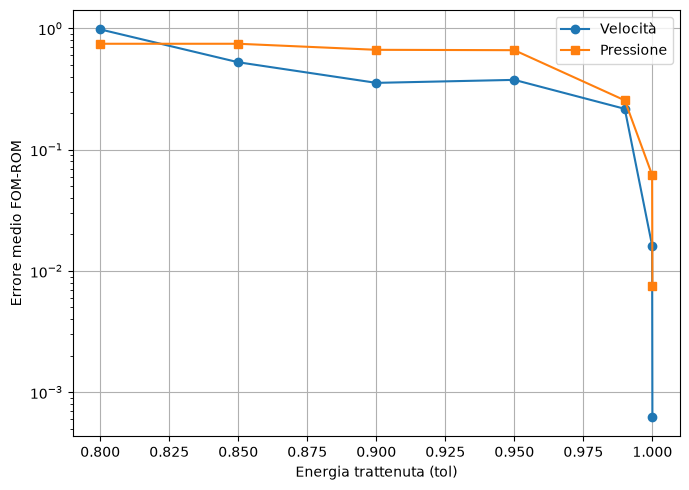

In [38]:
plt.close('all')

plt.figure(figsize=(7,5))
plt.semilogy(tolerances, err_u_mean, '-o', label='Velocità')
plt.semilogy(tolerances, err_p_mean, '-s', label='Pressione')

plt.xlabel("Energia trattenuta (tol)")
plt.ylabel("Errore medio FOM-ROM")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

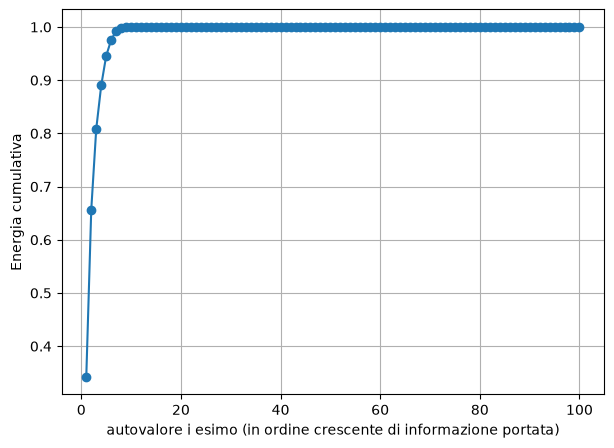

In [39]:
## GRAFICO: energia/informazione cumulata
energy = np.cumsum(eigvals)/np.sum(eigvals)

plt.figure(figsize=(7,5))

plt.plot(range(1,len(energy)+1), energy,'-o')

plt.xlabel("autovalore i esimo (in ordine crescente di informazione portata)")
plt.ylabel("Energia cumulativa")
plt.grid(True)

plt.show()

In [40]:
# proviamo ad aumentare il numero di snapshot, quindi studiamo la sensibilità a questo valore e fissiamo tolleranza alta dello 0.999999
snapshot_numbers = [2, 5, 8, 12, 16, 18, 20, 25]
tol = 0.99999

err_u_mean = []
err_p_mean = []


# ricavo 500 snapshots
np.random.seed(0)
training_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(snapshot_numbers[-1], P.shape[0]))

#### snapshot matrices creation

snapshot_matrix_u = []  # sia u_x che u_y
snapshot_matrix_s = [] ### supremizer snapshot
snapshot_matrix_p = []

print("Performing training...")
it = 0
for mu in training_set:
  if it % 10 == 0:
      print("\tIterations", 2 * it, " /", training_set.size)
  it = it + 1
  mu_0 = mu[0]
  mu_1 = mu[1]
    
  def pressure_strong_function(marker, x, y, z):  # definisco qui perchè dipende dai parametri
    return pressure_exact(x, y, z)
    
  p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
    
  def speed_x_strong_function(marker, x, y, z):   # definisco qui perchè dipende dai parametri
        return speed_x_exact(x, y, z)
  def speed_y_strong_function(marker, x, y, z):  # definisco qui perchè dipende dai parametri
        return speed_y_exact(x, y, z)
    
  u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_x_strong_function)
  u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_y_strong_function)
    
 
  def f_x_function(x, y, z):    # definisco qui perchè dipende dai parametri (nonostante la soluzione sia la stessa di stokes la forzante è diversa perchè c'è in più il termine convettivo
        ux = speed_x_exact(x, y, z)
        uy = speed_y_exact(x, y, z)
        convection = (ux * speed_x_exact_dx(x, y, z)+ uy * speed_x_exact_dy(x, y, z) )
        pressure = pressure_exact_gradient(x, y, z)[0]
        laplacian = speed_x_exact_laplacian(x, y, z)
        return -mu_0 * laplacian + convection + pressure
    
  def f_y_function(x, y, z):  # definisco qui perchè dipende dai parametri
        ux = speed_x_exact(x, y, z)
        uy = speed_y_exact(x, y, z)
        convection = (ux * speed_y_exact_dx(x, y, z)+ uy * speed_y_exact_dy(x, y, z))
        pressure = pressure_exact_gradient(x, y, z)[1]
        laplacian = speed_y_exact_laplacian(x, y, z)
        return -mu_0 * laplacian + convection + pressure
    

  J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y   # definisco jacobiano totale
  
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,   
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

  f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])  # forzante
    
  snapshot_solution, flag, num_iter, err_u, err_p, u_error_rel, p_error_rel = find_FOM_newton(J_S, f_S, u_x_strong, u_y_strong, speed_n_dofs, pressure_n_dofs, tot_dofs)  
    
  snapshot_u = snapshot_solution[0:2 * speed_n_dofs]
  snapshot_matrix_u.append(np.copy(snapshot_u))
  
  snapshot_p = snapshot_solution[2 * speed_n_dofs:]
  snapshot_matrix_p.append(np.copy(snapshot_p))

  snapshot_s = scipy.sparse.linalg.spsolve(X_1 + X_2, np.transpose(B_1 + B_2) @ snapshot_p)
  snapshot_matrix_s.append(np.copy(snapshot_s)) 

snapshot_matrix_u = np.array(snapshot_matrix_u)
snapshot_matrix_s = np.array(snapshot_matrix_s)
snapshot_matrix_p = np.array(snapshot_matrix_p)  

print("Training performed")

Performing training...
	Iterations 0  / 50
	Iterations 20  / 50
	Iterations 40  / 50
Training performed


In [41]:

for n_snap in snapshot_numbers:
    N_max = n_snap
    
    # Costruzione POD con i primi n_snap snapshot

    snapshot_u = snapshot_matrix_u[:n_snap]
    snapshot_s = snapshot_matrix_s[:n_snap]
    snapshot_p = snapshot_matrix_p[:n_snap]

    C_u = snapshot_u @ inner_product_u @ snapshot_u.T
    C_s = snapshot_s @ inner_product_u @ snapshot_s.T
    C_p = snapshot_p @ snapshot_p.T

    N_u, eigs_u = eig_analysis(C_u, N_max=N_max, tol=tol)
    N_s, eigs_s = eig_analysis(C_s, N_max=N_max, tol=tol)
    N_p, eigs_p = eig_analysis(C_p, N_max=N_max, tol=tol)

    basis_functions_u = create_basis_functions_matrix(N_u,snapshot_u,eigs_u,inner_product=inner_product_u)
    basis_functions_s = create_basis_functions_matrix( N_s, snapshot_s, eigs_s, inner_product=inner_product_u)
    basis_functions_p = create_basis_functions_matrix(N_p,snapshot_p,eigs_p)
    basis = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_s + N_p))
    basis[:basis_functions_u.shape[0], :N_u] = basis_functions_u
    basis[:basis_functions_u.shape[0], N_u:N_u+N_s] = basis_functions_s
    basis[basis_functions_u.shape[0]:, N_u+N_s:] = basis_functions_p


    err_u = []
    err_p = []

    for mu in testing_set:
        mu_0 = mu[0]
        J_S = mu_0*J_A_x + mu_0*J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

        # forzante
        def f_x_function(x,y,z):
            ux = speed_x_exact(x,y,z)
            uy = speed_y_exact(x,y,z)
            return (-mu_0*speed_x_exact_laplacian(x,y,z)+ ux*speed_x_exact_dx(x,y,z)  + uy*speed_x_exact_dy(x,y,z)  + pressure_exact_gradient(x,y,z)[0])

        def f_y_function(x,y,z):
            ux = speed_x_exact(x,y,z)
            uy = speed_y_exact(x,y,z)
            return (-mu_0*speed_y_exact_laplacian(x,y,z)+ ux*speed_y_exact_dx(x,y,z)+ uy*speed_y_exact_dy(x,y,z)+ pressure_exact_gradient(x,y,z)[1])

        f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term( geometry_utilities, mesh, mesh_geometric_data, speed_dofs_data, speed_reference_element_data, speed_reference_element_data,f_x_function)
        f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,mesh,mesh_geometric_data,speed_dofs_data,speed_reference_element_data,speed_reference_element_data,f_y_function)
        f_S = np.concatenate([f_x,f_y,np.zeros(pressure_n_dofs)])
        reduced_initial_solution = np.zeros(basis.shape[1])
        # ---------------- ROM ----------------
        ROM_solution, _, _, _, _, _, _, _ = find_ROM_newton(basis,J_S,f_S)
        # ---------------- FOM ----------------
        FOM_solution, _, _, _, _, _, _ = find_FOM_newton(J_S,f_S,u_x_strong,u_y_strong,speed_n_dofs,pressure_n_dofs,tot_dofs)

        err_u.append(compute_error( FOM_solution[:2*speed_n_dofs], ROM_solution[:2*speed_n_dofs], inner_product=inner_product_u))
        err_p.append(compute_error( FOM_solution[2*speed_n_dofs:], ROM_solution[2*speed_n_dofs:]))

    err_u_mean.append(np.mean(err_u))
    err_p_mean.append(np.mean(err_p))

    print(f"Snapshots = {n_snap:3d}   "
          f"Errore velocità = {err_u_mean[-1]:.2e}   "
          f"Errore pressione = {err_p_mean[-1]:.2e}")
    print(
    f"Snapshots={n_snap}, "
    f"Nu={N_u}, Ns={N_s}, Np={N_p}")

Snapshots =   2   Errore velocità = 9.32e-01   Errore pressione = 5.88e-01
Snapshots=2, Nu=2, Ns=2, Np=2
Snapshots =   5   Errore velocità = 9.09e-02   Errore pressione = 5.68e-02
Snapshots=5, Nu=5, Ns=5, Np=5
Snapshots =   8   Errore velocità = 2.74e-02   Errore pressione = 4.96e-02
Snapshots=8, Nu=8, Ns=7, Np=7
Snapshots =  12   Errore velocità = 4.89e-02   Errore pressione = 5.00e-02
Snapshots=12, Nu=8, Ns=8, Np=8
Snapshots =  16   Errore velocità = 8.79e-03   Errore pressione = 3.10e-02
Snapshots=16, Nu=9, Ns=10, Np=10
Snapshots =  18   Errore velocità = 9.78e-03   Errore pressione = 3.11e-02
Snapshots=18, Nu=9, Ns=10, Np=10
Snapshots =  20   Errore velocità = 1.01e-02   Errore pressione = 3.08e-02
Snapshots=20, Nu=9, Ns=10, Np=10
Snapshots =  25   Errore velocità = 1.01e-02   Errore pressione = 1.49e-02
Snapshots=25, Nu=10, Ns=12, Np=11


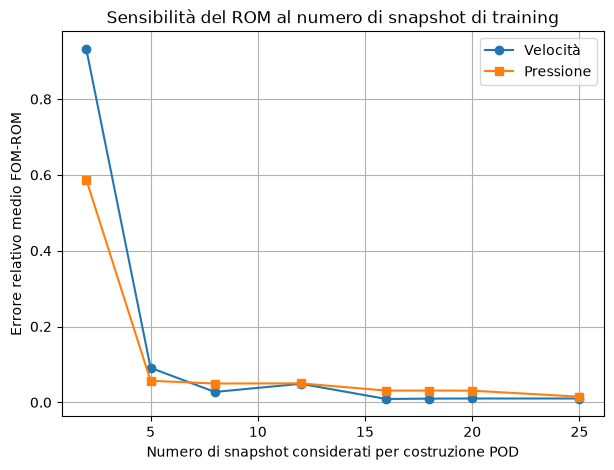

In [42]:
plt.figure(figsize=(7,5))

plt.plot(snapshot_numbers, err_u_mean, '-o', label='Velocità')
plt.plot(snapshot_numbers, err_p_mean, '-s', label='Pressione')

plt.xlabel("Numero di snapshot considerati per costruzione POD")
plt.ylabel("Errore relativo medio FOM-ROM")
plt.title("Sensibilità del ROM al numero di snapshot di training")
plt.grid(True)
plt.legend()

plt.show()